In [1]:
"Up and running"

'Up and running'

In [9]:
# Built-in modules
import json
from collections import defaultdict

# Third-party modules
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

# Custom modules
from misc import paths
from misc.logger import logger
from families.domain_architecture import DomainArchitecture
logger.info('Importing modules completed')

479594846.py INFO Importing modules completed


In [3]:
# Load clustering results
json_file = paths.FAMILIES / 'accession2representative.json'
with open(json_file, 'r') as handle:
    accession2representative = json.load(handle)

# Mapping representative to UniProt accessions
representative2accessions = defaultdict(list)
for accession, representative in accession2representative.items():
    representative = DomainArchitecture(representative)
    representative2accessions[representative].append(accession)

# Plot per-family protein distribution

Text(0.5, 1.0, 'Top 25 families by number of proteins')

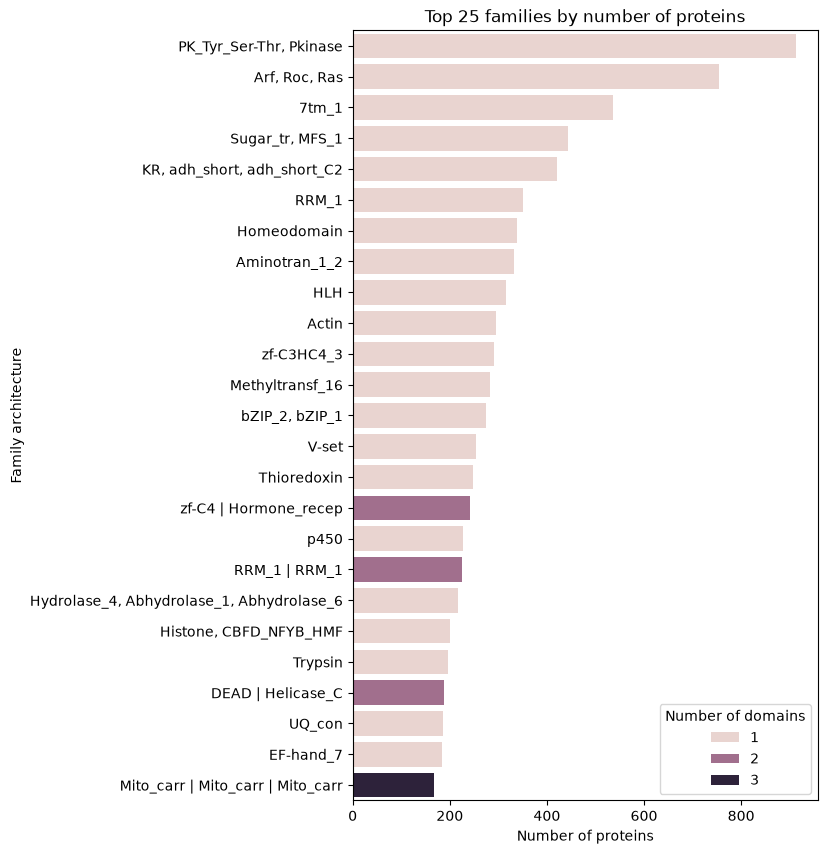

In [ ]:
# Build dataframe
df = {
    'Family architecture': [],
    'Number of proteins': [],
    'Number of domains': [],
}
for representative, accessions in representative2accessions.items():
    architecture = representative.as_pfam_names()
    df['Family architecture'].append(architecture.prettify())
    df['Number of proteins'].append(len(accessions))
    df['Number of domains'].append(len(representative))
df = pd.DataFrame(df)
df = df.sort_values(by='Number of proteins', ascending=False)

# Plot
NFAMS = 25
plt.figure(figsize=(6, 10))
sns.barplot(
    data=df.head(NFAMS),
    x='Number of proteins',
    y='Family architecture',
    hue='Number of domains',
)
plt.title(f'Top {NFAMS} families by number of proteins')

# Plot per-family interaction distribution

In [59]:
# Load interactions
file_path = paths.FAMILIES / 'interactions.txt'
df = pd.read_csv(file_path, sep='\t')

In [97]:
# Count interactions per family
architecture2interactions = {}
for row in tqdm(df.itertuples(index=False, name=None), total=len(df)):
    # Obtain architectures
    architecture1 = DomainArchitecture(accession2representative[row[0]])
    name1 = architecture1.as_pfam_names().prettify()
    architecture2 = DomainArchitecture(accession2representative[row[1]])
    name2 = architecture2.as_pfam_names().prettify()
    # Add framework for counting interactions
    if name1 not in architecture2interactions:
        architecture2interactions[name1] = [0, 0, len(architecture1)]
    if name2 not in architecture2interactions:
        architecture2interactions[name2] = [0, 0, len(architecture2)]
    # Count interactions
    if name1 == name2:
        architecture2interactions[name1][0] += 1
    else:
        architecture2interactions[name1][1] += 1
        architecture2interactions[name2][1] += 1

  0%|          | 0/600804 [00:00<?, ?it/s]

100%|██████████| 600804/600804 [00:28<00:00, 20845.80it/s]


In [48]:
# Build dataframe
df = pd.DataFrame.from_dict(
    architecture2interactions, 
    orient="index", 
    columns=["Intra", "Inter", "Number of domains"]
)
df['Total'] = df['Intra'] + df['Inter']
df = df.sort_values(by='Total', ascending=False)
df.reset_index(inplace=True, names=['Family architecture'])

Text(0.5, 0, 'Number of interactions')

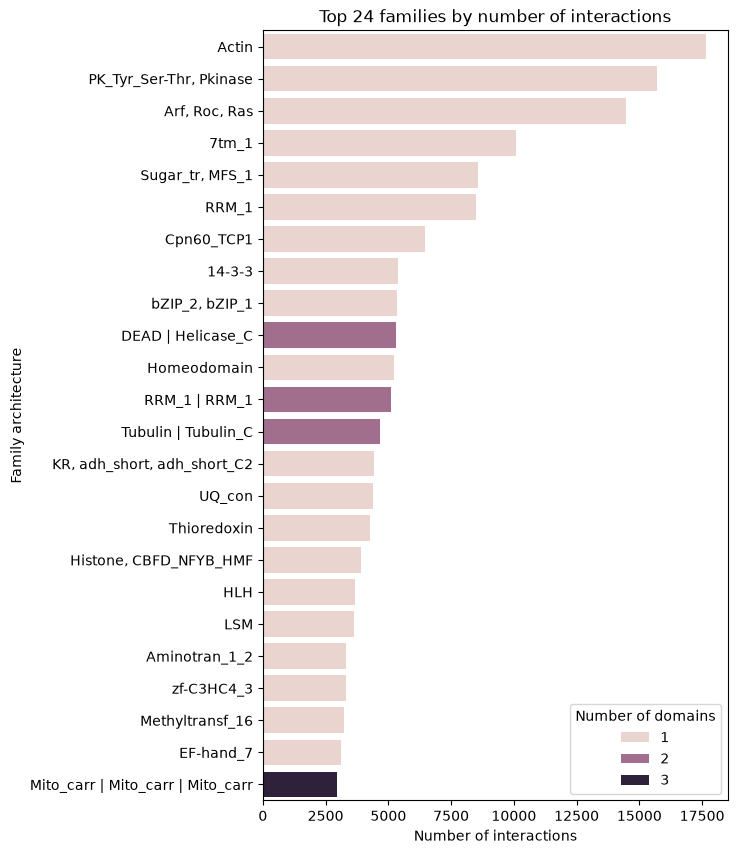

In [ ]:
# Plot 1
NFAMS = 24
plt.figure(figsize=(6, 10))
sns.barplot(
    data=df.head(NFAMS),
    x='Total',
    y='Family architecture',
    hue='Number of domains'
)
plt.title(f'Top {NFAMS} families by number of interactions')
plt.xlabel('Number of interactions')

In [ ]:
# Melt dataframe
df_long = df.head(NFAMS).melt(
    id_vars=['Family architecture', 'Number of domains'],
    value_vars=['Intra', 'Inter', 'Total'],
    var_name='Interaction type',
    value_name='Number of interactions'
)
df_long

,Family architecture,Number of domains,Interaction type,Number of interactions
0,Actin,1,Intra,201
1,"PK_Tyr_Ser-Thr, Pkinase",1,Intra,401
2,"Arf, Roc, Ras",1,Intra,499
3,7tm_1,1,Intra,196
4,"Sugar_tr, MFS_1",1,Intra,95
...,...,...,...,...
67,Aminotran_1_2,1,Total,3323
68,zf-C3HC4_3,1,Total,3297
69,Methyltransf_16,1,Total,3245
70,EF-hand_7,1,Total,3121


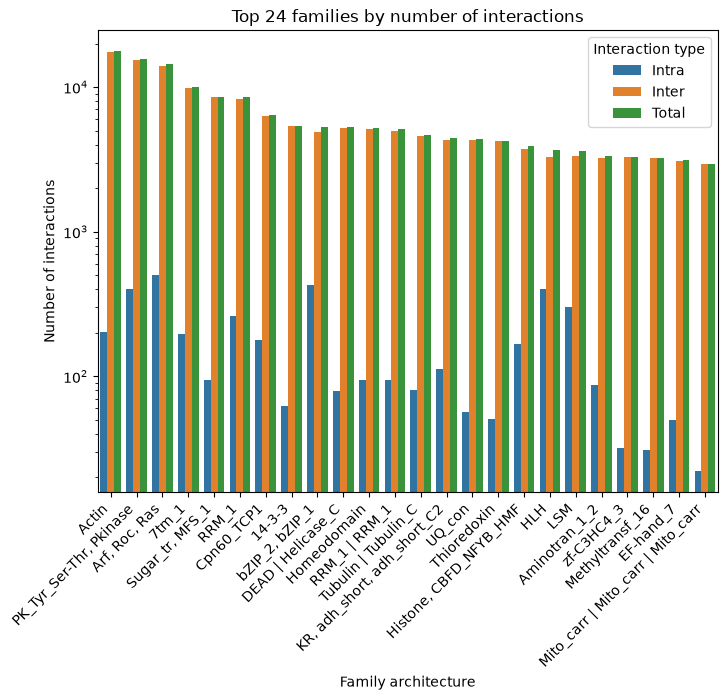

In [ ]:
# Plot 2
plt.figure(figsize=(8, 6))
sns.barplot(
    data=df_long,
    x="Family architecture",
    y="Number of interactions",
    hue="Interaction type"
)
plt.title(f'Top {NFAMS} families by number of interactions')
plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.show()